<a href="https://colab.research.google.com/github/mianorris314/RUSH-analytics/blob/code-edits-mianorris/GENBUS885_Final_Norris_M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RUSH Analytics

Mia Norris

RUSH is a globally renowned sportswear and footwear brand known for its innovative designs and performance-oriented products. The company stores its raw sales data as a collection of three tables:

- TABLE_PRODUCTS
- TABLE_RETAILER
- TABLE_SALES

In [1]:
#Importing the relevant libraries
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt

In [2]:
#Set up the tables
uploaded = files.upload()

Saving TABLE_PRODUCTS_885.csv to TABLE_PRODUCTS_885 (10).csv
Saving TABLE_RETAILER_885.csv to TABLE_RETAILER_885 (10).csv
Saving TABLE_SALES_885.csv to TABLE_SALES_885 (10).csv


In [3]:
products_df = pd.read_csv("TABLE_PRODUCTS_885.csv", sep="|")
products_df.head()

,PRODUCT_ID,PRODUCT_NAME
0,20,Men's Street Footwear
1,30,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,40,Men's Apparel


In [4]:
sales_df = pd.read_csv('TABLE_SALES_885.csv')
sales_df.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet


In [5]:
retailer_df = pd.read_csv('TABLE_RETAILER_885.csv')
retailer_df.head()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


**Data Inspection**

Checking for data types

In [6]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PRODUCT_ID    6 non-null      int64 
 1   PRODUCT_NAME  6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [7]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          9648 non-null   int64  
 1   RETAILER_ID       9648 non-null   object 
 2   INVOICE_DATE      9648 non-null   object 
 3   MONTH             9648 non-null   int64  
 4   DAY               9648 non-null   int64  
 5   YEAR              9648 non-null   int64  
 6   PRODUCT_ID        9648 non-null   int64  
 7   PRICE_PER_UNIT    9646 non-null   float64
 8   UNITS_SOLD        9648 non-null   object 
 9   OPERATING_MARGIN  9648 non-null   float64
 10  SALES_METHOD      9648 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 829.3+ KB


In [8]:
retailer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   RETAILER_ID  110 non-null    object
 1   RETAILER     110 non-null    object
 2   REGION       110 non-null    object
 3   STATE        110 non-null    object
 4   CITY         110 non-null    object
dtypes: object(5)
memory usage: 4.4+ KB


Checking for null values

In [9]:
products_df.isnull().sum()

,0
PRODUCT_ID,0
PRODUCT_NAME,0


In [10]:
sales_df.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,2
UNITS_SOLD,0
OPERATING_MARGIN,0


In [11]:
retailer_df.isnull().sum()

,0
RETAILER_ID,0
RETAILER,0
REGION,0
STATE,0
CITY,0


Looking for erroneous values and outliers

In [12]:
products_df.describe()

,PRODUCT_ID
count,6.000000
mean,80.000000
std,55.497748
min,20.000000
25%,32.500000
50%,80.000000
75%,127.500000
max,140.000000


In [13]:
sales_df.describe()

,ORDER_ID,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,OPERATING_MARGIN
count,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000,9646.000000,9648.000000
mean,4824.500000,6.458126,14.696310,2020.865050,79.975124,55.575264,0.422991
std,2785.282032,3.454799,7.348019,0.341688,50.668992,1017.819943,0.097197
min,1.000000,1.000000,1.000000,2020.000000,20.000000,7.000000,0.100000
25%,2412.750000,3.000000,9.000000,2021.000000,30.000000,35.000000,0.350000
50%,4824.500000,6.000000,15.000000,2021.000000,40.000000,45.000000,0.410000
75%,7236.250000,9.000000,21.000000,2021.000000,130.000000,55.000000,0.490000
max,9648.000000,12.000000,31.000000,2021.000000,140.000000,99999.000000,0.800000


In [14]:
retailer_df.describe()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
count,110,110,110,110,110
unique,106,6,5,50,52
top,W00SFLOR,Foot Locker,Northeast,Florida,Charleston
freq,2,33,28,6,4


In [15]:
#checking categorical columns for typos and unexpected values
def check_categorical_columns(df):
    for col in df.select_dtypes(include="object").columns:
        print(f"{col}:")
        print(df[col].value_counts())
        print()

check_categorical_columns(sales_df)

RETAILER_ID:
RETAILER_ID
W00SARLI     216
W00WUTSA     216
W00WORPO     216
W00WNELA     216
S00STEDA     204
            ... 
S00MMOBI       8
S00MNEOM       8
W00NMAPO       8
W00MOHCO       8
999999999      1
Name: count, Length: 107, dtype: int64

INVOICE_DATE:
INVOICE_DATE
1/17/2021     77
8/17/2021     72
3/16/2021     72
4/17/2021     72
11/17/2021    71
              ..
10/10/2020     2
11/27/2020     2
12/3/2020      2
12/9/2020      2
12/15/2020     2
Name: count, Length: 724, dtype: int64

UNITS_SOLD:
UNITS_SOLD
225    207
150    202
175    191
300    189
200    174
      ... 
16       1
286      1
347      1
352      1
355      1
Name: count, Length: 362, dtype: int64

SALES_METHOD:
SALES_METHOD
Online      4889
Outlet      2999
In-store    1740
Ootlet        20
Name: count, dtype: int64



In [16]:
check_categorical_columns(products_df)

PRODUCT_NAME:
PRODUCT_NAME
Men's Street Footwear        1
Men's Athletic Footwear      1
Women's Street Footwear      1
Women's Athletic Footwear    1
Men's Apparel                1
Women's Apparel              1
Name: count, dtype: int64



In [17]:
check_categorical_columns(retailer_df)

RETAILER_ID:
RETAILER_ID
W00SFLOR    2
S00NNENE    2
W00SARLI    2
W00STEHO    2
A00NVEBU    1
           ..
W00WIDBO    1
W00WNELA    1
W00WORPO    1
W00WUTSA    1
W00WWASE    1
Name: count, Length: 106, dtype: int64

RETAILER:
RETAILER
Foot Locker      33
Sports Direct    26
West Gear        24
Kohl's           12
Amazon            9
Walmart           6
Name: count, dtype: int64

REGION:
REGION
Northeast    28
Midwest      24
West         24
South        18
Southeast    16
Name: count, dtype: int64

STATE:
STATE
Florida           6
New York          5
Texas             5
California        4
Idaho             3
Mississippi       3
Maryland          3
Hawaii            3
Alaska            2
Illinois          2
Massachusetts     2
New Hampshire     2
Vermont           2
Alabama           2
Kentucky          2
North Carolina    2
Ohio              2
Maine             2
South Dakota      2
North Dakota      2
Nebraska          2
Missouri          2
Minnesota         2
Michigan          2


In [18]:
#checking for sales rows whose RETAILER_ID has no match in the retailer table
orphans = set(sales_df["RETAILER_ID"]) - set(retailer_df["RETAILER_ID"])
sales_df[sales_df["RETAILER_ID"].isin(orphans)]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
1446,8668,999999999,7/23/2021,7,23,2021,20,60.0,298,0.42,Outlet


**Data Inspection Findings:** <br>
- all three dataframes can be merged into one for easier analysis

sales_df
- outlet is mispelled as ootlet in several rows
- price per unit has 99999 as a placeholder value
- units sold has two rows with *** instead of a number
- invoice data should be converted to a date object
- there are two nulls in price per unit
- one order references RETAILER_ID 999999999, a placeholder with no matching retailer record; keeping the row for product-level totals, but it will show as null for retailer and location

retailer_df
- there are 110 retailer_ids and 106 unique values

**Data Cleaning**

sales_df cleaning

In [19]:
#SALES_METHOD contains a misspelling of "Outlet"
sales_df["SALES_METHOD"] = sales_df["SALES_METHOD"].replace("Ootlet", "Outlet")

#confirming only valid values are left
print(sales_df["SALES_METHOD"].value_counts())

SALES_METHOD
Online      4889
Outlet      3019
In-store    1740
Name: count, dtype: int64


In [20]:
#PRICE_PER_UNIT has one value of 99999, which is a placeholder rather than a real price
#every other price falls between $7 and $110, so treating it as missing
sales_df.loc[sales_df["PRICE_PER_UNIT"] > 1000, "PRICE_PER_UNIT"] = None

#confirming the price range is now reasonable
print("Minimum price:", sales_df["PRICE_PER_UNIT"].min(), "Maximum price:", sales_df["PRICE_PER_UNIT"].max())

Minimum price: 7.0 Maximum price: 110.0


In [21]:
#units sold has two rows with *** instead of a number
#coerce so that '***' becomes NaN
sales_df["UNITS_SOLD"] = pd.to_numeric(sales_df["UNITS_SOLD"], errors="coerce")

#dropping these rows since this is an extremely important data point
sales_df = sales_df.dropna(subset=["UNITS_SOLD"])

#cast the remaining values to an integer
sales_df["UNITS_SOLD"] = sales_df["UNITS_SOLD"].astype(int)

In [22]:
#invoice date should be converted to a date object
sales_df["INVOICE_DATE"] = pd.to_datetime(sales_df["INVOICE_DATE"], format="%m/%d/%Y")
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9646 entries, 0 to 9647
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDER_ID          9646 non-null   int64         
 1   RETAILER_ID       9646 non-null   object        
 2   INVOICE_DATE      9646 non-null   datetime64[ns]
 3   MONTH             9646 non-null   int64         
 4   DAY               9646 non-null   int64         
 5   YEAR              9646 non-null   int64         
 6   PRODUCT_ID        9646 non-null   int64         
 7   PRICE_PER_UNIT    9643 non-null   float64       
 8   UNITS_SOLD        9646 non-null   int64         
 9   OPERATING_MARGIN  9646 non-null   float64       
 10  SALES_METHOD      9646 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(6), object(2)
memory usage: 904.3+ KB


In [23]:
#there are two nulls in price per unit
#filling price per unit with the median for that product
sales_df["PRICE_PER_UNIT"] = sales_df["PRICE_PER_UNIT"].fillna(
    sales_df.groupby("PRODUCT_ID")["PRICE_PER_UNIT"].transform("median")
)
sales_df.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,0
UNITS_SOLD,0
OPERATING_MARGIN,0


retailer_df cleaning

In [24]:
#there are 110 retailer_ids and 106 unique values
#isolate the problem rows to review
dupes = retailer_df[retailer_df.duplicated(subset=["RETAILER_ID"], keep=False)].sort_values("RETAILER_ID")
print(dupes)

#keeping the first occurrence of each RETAILER_ID so the merge doesn't duplicate sales rows
retailer_clean = retailer_df.drop_duplicates(subset=["RETAILER_ID"], keep="first")

#confirming every RETAILER_ID is now unique
print("\nRows before:", len(retailer_df), "| Rows after:", len(retailer_clean))
print("Unique RETAILER_IDs:", retailer_clean["RETAILER_ID"].nunique())

    RETAILER_ID       RETAILER     REGION       STATE         CITY
63     S00NNENE  Sports Direct  Northeast  New Jersey       Newark
64     S00NNENE  Sports Direct  Northeast    New York     New York
81     W00SARLI        Walmart      South    Arkansas  Little Rock
97     W00SARLI      West Gear      South    Arkansas  Little Rock
84     W00SFLOR        Walmart  Southeast     Florida      Orlando
102    W00SFLOR      West Gear  Southeast     Florida      Orlando
83     W00STEHO        Walmart      South       Texas      Houston
100    W00STEHO      West Gear      South       Texas      Houston

Rows before: 110 | Rows after: 106
Unique RETAILER_IDs: 106


4 retailer IDs were non-unique in the source data. Because `RETAILER_ID` is the primary key used to join the sales and retailer tables, leaving the duplicates in causes the merge to match those sales rows twice, inflating row count from 9,646 to 10,269 and double-counting revenue for ~623 transactions.

Since I cannot determine from the source data which record is correct, I kept the first occurrence of each ID. This preserves accurate sales totals, but means region/city-level results for those transactions may be attributed to the wrong location.

Merging the tables for easier analysis

In [25]:
#merging all three tables into one dataframe for easier analysis
full_df = (sales_df
           .merge(retailer_clean, on="RETAILER_ID", how="left")
           .merge(products_df, on="PRODUCT_ID", how="left"))

#confirming the merge didn't duplicate or drop any sales rows
print("sales_df rows:", len(sales_df), "| full_df rows:", len(full_df))
full_df.head()

sales_df rows: 9646 | full_df rows: 9646


,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,RETAILER,REGION,STATE,CITY,PRODUCT_NAME
0,1,A00MOHCO,2020-01-01,1,1,2020,20,50.0,1200,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
1,7,A00MOHCO,2020-01-07,1,7,2020,20,50.0,1250,0.5,In-store,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
2,13,A00MOHCO,2020-01-25,1,25,2020,20,50.0,1220,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
3,19,A00MOHCO,2020-01-31,1,31,2020,20,50.0,1200,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
4,25,A00MOHCO,2020-02-06,2,6,2020,20,60.0,1220,0.5,Outlet,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear


**Data Analysis for Trends**

There was a large jump in revenue in 2021. In both years, we can see that there is seasonality in revenue, with peaks around July and December.

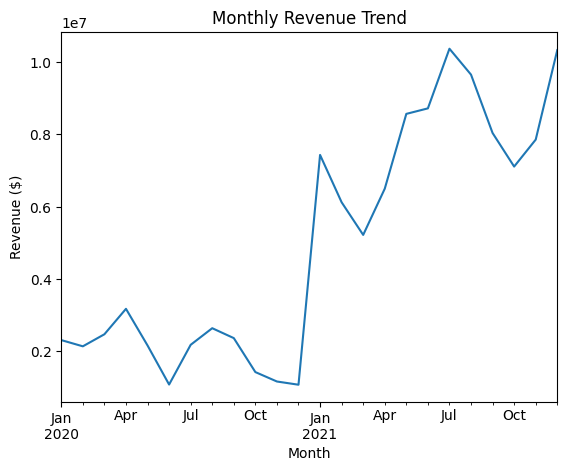

In [26]:
#monthly analysis of revenue
full_df["REVENUE"] = full_df["UNITS_SOLD"] * full_df["PRICE_PER_UNIT"]
monthly_revenue = full_df.groupby(full_df["INVOICE_DATE"].dt.to_period("M"))["REVENUE"].sum()
monthly_revenue.plot(title="Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.show()

Similar to revenue, there was a large jump in units sold in 2021. In both years, we can see that there is seasonality in units sold, with peaks around July and December.

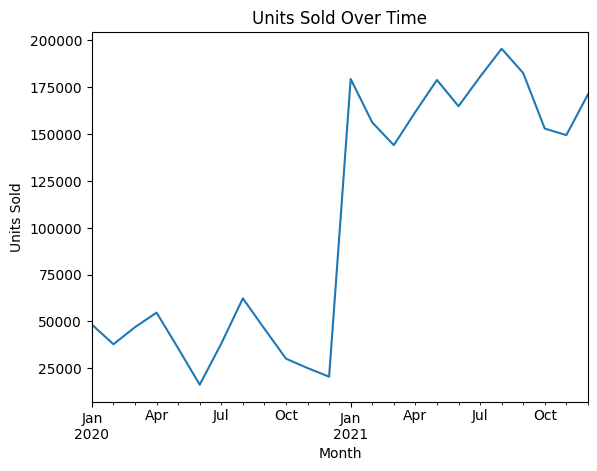

In [27]:
#units sold over time
units_over_time = full_df.groupby(full_df["INVOICE_DATE"].dt.to_period("M"))["UNITS_SOLD"].sum()
units_over_time.plot(title="Units Sold Over Time")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

Foot Locker is our largest retailer at roughly 1.1 million units, more than double Amazon in second place. Walmart is our smallest at under 60,000 units.

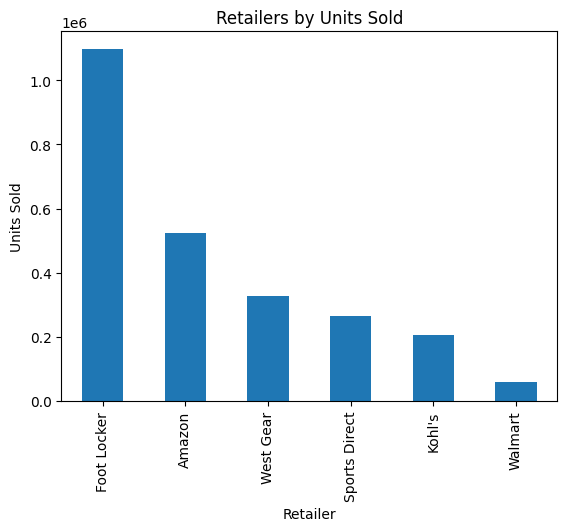

In [28]:
#retailers by units sold
retailer_units = full_df.groupby("RETAILER")["UNITS_SOLD"].sum().sort_values(ascending=False)
retailer_units.plot(kind="bar", title="Retailers by Units Sold")
plt.xlabel("Retailer")
plt.ylabel("Units Sold")
plt.show()

Men's Street Footwear is our leader at 592,939 units. Men's Athletic Footwear and Women's Apparel are nearly tied for second at ~435,000 units each.

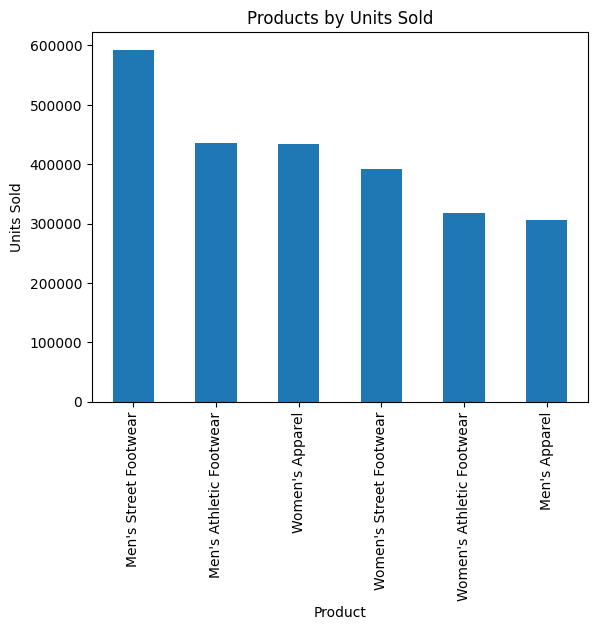

In [29]:
#products by units sold
product_units = full_df.groupby("PRODUCT_NAME")["UNITS_SOLD"].sum().sort_values(ascending=False)

product_units.plot(kind="bar", title="Products by Units Sold")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.show()

Online pulled ahead of other methods from June 2021 onward while Outlet revenue declined.

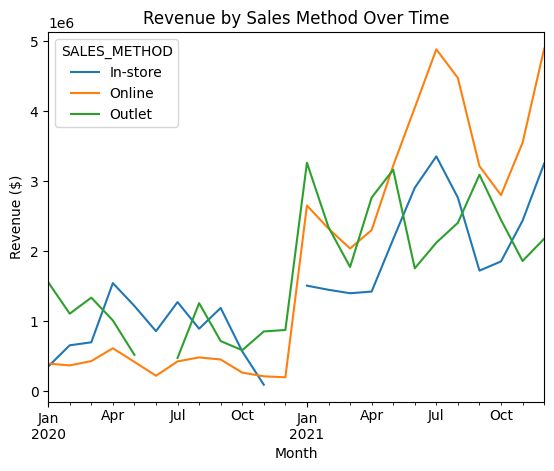

In [30]:
#revenue by sales method over time
method_trend = full_df.groupby([full_df["INVOICE_DATE"].dt.to_period("M"), "SALES_METHOD"])["REVENUE"].sum().unstack()
method_trend.plot(title="Revenue by Sales Method Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.show()

Margins are tight across the board, so category mix barely moves profitability. Men's Street Footwear happens to be both the highest-volume and highest-margin category.

In [31]:
#average operating margin by product category
full_df.groupby("PRODUCT_NAME")["OPERATING_MARGIN"].mean().sort_values(ascending=False)

,OPERATING_MARGIN
PRODUCT_NAME,
Men's Street Footwear,0.446119
Women's Apparel,0.441318
Women's Athletic Footwear,0.424359
Men's Apparel,0.413225
Women's Street Footwear,0.410199
Men's Athletic Footwear,0.402702


Northeast leads at \$38.8 million, South has the least revenue at \$10.3 million with the Southeast close at \$14.7 million, showing us a large area for growth in South and Southeast regions.

In [32]:
#revenue by region
full_df.groupby("REGION")["REVENUE"].sum().sort_values(ascending=False)

,REVENUE
REGION,
Northeast,38818538.0
Midwest,31433570.0
West,24820550.0
Southeast,14726189.0
South,10317224.0


Foot Locker and Walmart show NaN for 2020, then Foot Locker posts 1,097,410 units in 2021. Foot Locker came from no units sold to being the #1 retailer.

Amazon is the only retailer that declined, 317,930 to 205,570.

In [33]:
#retailer units, 2020 vs 2021
full_df.pivot_table(index="RETAILER", columns="YEAR", values="UNITS_SOLD", aggfunc="sum")

YEAR,2020,2021
RETAILER,,
Amazon,317930.0,205570.0
Foot Locker,NaN,1097410.0
Kohl's,68686.0,136950.0
Sports Direct,18399.0,248131.0
Walmart,NaN,58286.0
West Gear,57334.0,269486.0


**Answering the Business Questions**

What product category (product) had the highest sales (in dollars) in 2021? How much did it sell? <br>
*Men's Street Footwear	with a revenue of $22,672,800.0 and 493,753 units sold.*

In [34]:
full_df_2021 = full_df[full_df["YEAR"] == 2021]
product_category_sales = full_df_2021.groupby("PRODUCT_NAME")["REVENUE"].sum().sort_values(ascending=False)
product_category_units = full_df_2021.groupby("PRODUCT_NAME")["UNITS_SOLD"].sum().sort_values(ascending=False)
product_category_sales

,REVENUE
PRODUCT_NAME,
Men's Street Footwear,22672800.0
Women's Apparel,19178278.0
Men's Athletic Footwear,16339593.0
Women's Street Footwear,13535783.0
Men's Apparel,13025293.0
Women's Athletic Footwear,11160629.0


In [35]:
product_category_units

,UNITS_SOLD
PRODUCT_NAME,
Men's Street Footwear,493753
Men's Athletic Footwear,353766
Women's Apparel,353619
Women's Street Footwear,316478
Women's Athletic Footwear,253059
Men's Apparel,245456


What state had the highest sales (in dollars) of women's products in 2021? How much was it? <br>
*Maine with $2,176,301.0 in revenue.*


In [36]:
#checking how to identify women's products
print(full_df_2021["PRODUCT_NAME"].unique())

["Men's Street Footwear" "Men's Athletic Footwear" "Men's Apparel"
 "Women's Street Footwear" "Women's Athletic Footwear" "Women's Apparel"]


In [37]:
womens_df = full_df_2021[full_df_2021["PRODUCT_NAME"].str.contains("Women's")]
womens_state_sales = womens_df.groupby("STATE")["REVENUE"].sum().sort_values(ascending=False)
womens_state_sales

,REVENUE
STATE,
Maine,2176301.0
Delaware,2023575.0
New Hampshire,1916400.0
Arizona,1798900.0
Missouri,1771992.0
Illinois,1743277.0
Virginia,1719886.0
Nebraska,1712680.0
Connecticut,1600156.0


What state had the highest sales (in dollars) of men's products in 2021? How much was it? <br>
*Delaware with $2,334,300.0 in revenue.*

In [38]:
mens_df = full_df_2021[full_df_2021["PRODUCT_NAME"].str.contains("Men's")]
mens_state_sales = mens_df.groupby("STATE")["REVENUE"].sum().sort_values(ascending=False)
mens_state_sales

,REVENUE
STATE,
Delaware,2334300.0
Arizona,2261025.0
New Hampshire,2232000.0
Maine,2217190.0
Illinois,2093438.0
Missouri,1951530.0
Connecticut,1926568.0
New York,1847069.0
Nebraska,1718726.0


What retailer purchased the most units in 2021? <br>
*Foot Locker with 1,097,410 units sold.*

In [39]:
full_df_2021.groupby("RETAILER")["UNITS_SOLD"].sum().sort_values(ascending=False)

,UNITS_SOLD
RETAILER,
Foot Locker,1097410
West Gear,269486
Sports Direct,248131
Amazon,205570
Kohl's,136950
Walmart,58286


What retailer purchased the most units in 2020? <br>
*Amazon with 317,930 units sold.*


In [40]:
full_df_2020 = full_df[full_df["YEAR"] == 2020]
full_df_2020.groupby("RETAILER")["UNITS_SOLD"].sum().sort_values(ascending=False)

,UNITS_SOLD
RETAILER,
Amazon,317930
Kohl's,68686
West Gear,57334
Sports Direct,18399
